# Figure SX: SO-EPT Coupling and SWCF - Historical vs. PiControl 

This analysis sanity checks that SO-EPT Coupling and SWCF calculate from piControl as similar to those derived from historical. This analysis is in response to a reviewer comment

In [21]:
import xarray as xr
import xcdat as xc
import numpy as np
import xskillscore as xscore
import matplotlib.pyplot as plt
import os
from numpy.polynomial.polynomial import polyfit, polyval

# Utils

In [22]:
def fix_coords(data):
    data = data.bounds.add_bounds("X")
    data = data.bounds.add_bounds("Y")
    data = data.bounds.add_bounds("T")
    data = xc.swap_lon_axis(data, to=(-180, 180))
    return data

def remove_land_full(ds, var="skt"):
    ds = xc.swap_lon_axis(ds, to=(-180, 180))
    from global_land_mask import globe
    # Set land to NaN
    lon_grid,lat_grid = np.meshgrid(ds.lon, ds.lat)
    globe_land_mask = globe.is_land(lat_grid,lon_grid)
    globe_land_mask_nd = np.tile(globe_land_mask,(ds[var].shape[0],ds[var].shape[1], 1,1))
    ds_no_land = xr.where(globe_land_mask_nd==True,np.nan,ds[var]) 
    return ds_no_land


def get_rolling_timeseries(data: xr.DataArray, window: int = 12*30, step: int = 12, save: bool = False, name: str = "", gradient: bool = False) -> xr.DataArray:
    """Get the rolling timeseries of a dataset (optionally calculate gradient)

    Args:
        data (xr.DataArray): Input data.
        window (int, optional): Size of the rolling window. Defaults to 12*30.
        step (int, optional): Step size for each window. Defaults to 12.
        gradient (bool, optional): Calculate gradient if True, mean if False. Defaults to False.

    Returns:
        xr.DataArray: Resulting timeseries with same shape as input.
    """
    
    # Prepare output array with the same shape as input data
    new_time_size = 1 + (len(data.time) - window) // step
    rolling_shape = list(data.shape)
    rolling_shape[data.get_axis_num('time')] = new_time_size

    # Prepare output array with the adjusted shape
    rolling = np.full(rolling_shape, np.nan)
    time_idx = xr.DataArray(np.arange(window), dims="time")

    data = data.chunk({"time": -1})
    # Loop to compute rolling statistics over time dimension
    for j, i in enumerate(range(0, len(data.time) - window, step)):
        if gradient:
            rolling[:,j] = window*xscore.linslope(time_idx, data.isel(time=slice(i, i+window)), dim='time', skipna=True).values
        else:
            rolling[:,j] = data.isel(time=slice(i, i+window)).mean(dim="time").values

    # Convert to xarray
    da = xr.DataArray(rolling, dims=data.dims, coords={**data.coords, 'time': np.arange(rolling.shape[1])})

    return da


def lagged_regression(ts_so_ssts, ts_ept_ssts, lags, models):
    reg_coeffs, rvalues, pvalues = [], [], []
    for lag in lags:
        rvalues.append(xscore.pearson_r(ts_so_ssts.shift(time=lag), ts_ept_ssts, dim="time", skipna=True))
        reg_coeffs.append(xscore.linslope(ts_so_ssts.shift(time=lag), ts_ept_ssts, dim="time", skipna=True))
        pvalues.append(xscore.pearson_r_eff_p_value(ts_so_ssts.shift(time=lag), ts_ept_ssts, dim="time", skipna=True))


    reg_coeffs = xr.Dataset({'reg': (['lags', 'model'], np.array(reg_coeffs))}, coords={'model': models, 'lags': lags})
    rvalues = xr.Dataset({'rvalues': (['lags', 'model'], np.array(rvalues))}, coords={'model': models, 'lags': lags})
    pvalues = xr.Dataset({'pvalues': (['lags', 'model'], np.array(pvalues))}, coords={'model': models, 'lags': lags})
    # Combine to xr.Datasets into one
    regs_dataset = xr.merge([rvalues, reg_coeffs, pvalues])
    return regs_dataset


def get_triangle(tos, latmin: float = -38.75, latmax: float = -1.25, lonmin: float = -178.75, lonmax: float = -71.25, RES: float = 2.5):
    DY = latmax - latmin
    DX = lonmax - lonmin 
    dx = RES*round(DX/DY)
    dy = RES

    print(f"For each latitude step of {dy} degrees, longitude step is {dx}")

    latcoords = np.arange(latmax, latmin-dy, -dy)
    loncoords = np.arange(lonmin, lonmax+dx, dx)
    lonraw = np.arange(lonmin, lonmax+dx, RES)

    ctos = tos.sel(lon=slice(lonmin, lonmax), lat=slice(latmin, latmax))
    nmodel, ntime, _, nlon = ctos.shape
    # print(ctos)

    for i, clon in enumerate(lonraw):
        j = np.where(clon == loncoords)[0]

        if i == nlon: break

        # print("j prior: ", j)
        if len(j) == 0: 
            j = jold
        else: 
            j = j[0]
             
        # print("j: ", j)
        nlats = int(len(latcoords) - j) # nlats below diag
        # print("nlats: ", nlats)
        ctos[:,:,:nlats,i] = np.full((nmodel, ntime, nlats), np.nan) 
        
        jold = j
    
    return ctos

def detrend(da):
    da = da.chunk(dict(time=-1))
    time_idx = xr.DataArray(np.arange(len(da.time), dtype="float32"), dims="time")
    slope = xscore.linslope(time_idx, da, dim="time", skipna=True)
    da = da - slope*time_idx
    return da 

def poly_detrend(da, deg=2):
    da = da.chunk(dict(time=-1))
    time_idx = xr.DataArray(np.arange(len(da.time), dtype="float32"), dims="time")

    def fit_and_remove_poly(y):
        mask = np.isfinite(y)
        if mask.sum() < deg + 1:
            return y  # not enough points
        coeffs = polyfit(time_idx[mask], y[mask], deg)
        trend = polyval(time_idx, coeffs)
        return y - trend

    da_dt = xr.apply_ufunc(
        fit_and_remove_poly,
        da,
        input_core_dims=[["time"]],
        output_core_dims=[["time"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[da.dtype],
    )
    return da_dt



# Preprocess

In [ ]:
# Loading PiControl data
def load_cmip_data(fp):
    """Load CMIP data from a given file path."""
    # Open the dataset with xarray
    cmip_monthly_ssts = xr.open_dataset(fp, chunks="auto")
    # Fix coordinates and remove land
    cmip_monthly_ssts = fix_coords(remove_land_full(cmip_monthly_ssts, var="tos").to_dataset())
    # Detrend
    # cmip_monthly_ssts["tos"] = detrend(cmip_monthly_ssts["tos"])
    cmip_monthly_ssts["tos"] = poly_detrend(cmip_monthly_ssts["tos"], deg=2)

    # Get the EPT SSTs 
    cmip_ept_ssts = fix_coords(get_triangle(cmip_monthly_ssts.tos.copy(deep=True)).to_dataset()).spatial.average("tos").temporal.departures("tos", "month")["tos"]
    # Get the SO SSTs
    cmip_so_ssts = cmip_monthly_ssts.sel(lon=slice(-180, -75), lat=slice(-70, -50)).spatial.average("tos").temporal.departures("tos", "month")["tos"]

    return cmip_so_ssts, cmip_ept_ssts

so6_pi, ept6_pi = load_cmip_data("/home/espinosa10/tropical_pacific_clouds/data/piControl/tos_mon_1850-2100_CMIP5_piControl.nc")
so6_hi, ept6_hi = load_cmip_data("/home/espinosa10/tropical_pacific_clouds/data/historical/tos_mon_1850-2100_CMIP6_historical.nc")
so6_hi = so6_hi.load()
ept6_hi = ept6_hi.load()

For each latitude step of 2.5 degrees, longitude step is 7.5


/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing with an out-of-order index is generating 150 times more chunks
  return self.array[key]
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing with an out-of-order index is generating 150 times more chunks
  return self.array[key]


For each latitude step of 2.5 degrees, longitude step is 7.5


/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing with an out-of-order index is generating 165 times more chunks
  return self.array[key]
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing with an out-of-order index is generating 165 times more chunks
  return self.array[key]


In [ ]:
def calculate_coupling_depending_on_time(so_ssts, ept_ssts, models):
    min_year, max_year = 1, 30
    months = np.arange(1, 12)
    years = np.arange(min_year*12, (max_year+1)*12, 12)

    time = [*months, *years]
    # time = [60]
    reg_coeffs, rvalues, pvalues, variance_so, variance_ept = [], [], [], [], []
    for year in time:
        ts_so_ssts = get_rolling_timeseries(so_ssts, window=year, step=12, gradient=False)
        ts_ept_ssts = get_rolling_timeseries(ept_ssts, window=year, step=12, gradient=False)

        variance_ept.append(ts_ept_ssts.std(dim="time"))
        variance_so.append(ts_so_ssts.std(dim="time"))
        rvalues.append(xscore.pearson_r(ts_so_ssts, ts_ept_ssts, dim="time", skipna=True))
        pvalues.append(xscore.pearson_r_eff_p_value(ts_so_ssts, ts_ept_ssts, dim="time", skipna=True))
        reg_coeffs.append(xscore.linslope(ts_so_ssts, ts_ept_ssts, dim="time", skipna=True))

    reg_coeffs = xr.Dataset({'reg': (['years', 'model'], np.array(reg_coeffs))}, coords={'model': models, 'years': time})
    rvalues = xr.Dataset({'rvalues': (['years', 'model'], np.array(rvalues))}, coords={'model': models, 'years': time})
    pvalues = xr.Dataset({'pvalues': (['years', 'model'], np.array(pvalues))}, coords={'model': models, 'years': time})
    variance_so = xr.Dataset({'variance_so': (['years', 'model'], np.array(variance_so))}, coords={'model': models, 'years': time})
    variance_ept = xr.Dataset({'variance_ept': (['years', 'model'], np.array(variance_ept))}, coords={'model': models, 'years': time})

    # Combine to xr.Datasets into one
    regs_dataset = xr.merge([rvalues, reg_coeffs, pvalues, variance_so, variance_ept])
    return regs_dataset

# Historical Coupling
if not os.path.exists("/home/espinosa10/SO-EP-teleconnection/Data/so_ept_coupling_historical_poly-detrended.nc"):
    so_ept_coupling_hi = calculate_coupling_depending_on_time(so6_hi, ept6_hi, models=ept6_hi.model)
    so_ept_coupling_hi.to_netcdf("/home/espinosa10/SO-EP-teleconnection/Data/so_ept_coupling_historical_poly-detrended.nc")
else: 
    so_ept_coupling_hi = xr.open_dataset("/home/espinosa10/SO-EP-teleconnection/Data/so_ept_coupling_historical_poly-detrended.nc")

# PiControl Coupling
if not os.path.exists("/home/espinosa10/SO-EP-teleconnection/Data/so_ept_coupling.nc"):
    so_ept_coupling_pi = calculate_coupling_depending_on_time(so6_pi, ept6_pi, models=ept6_pi.model)
    so_ept_coupling_pi.to_netcdf("/home/espinosa10/SO-EP-teleconnection/Data/so_ept_coupling.nc")
else: 
    so_ept_coupling_pi = xr.open_dataset("/home/espinosa10/SO-EP-teleconnection/Data/so_ept_coupling.nc")

/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:410: RuntimeWarning: invalid value encountered in divide
  _x = dof / (dof + t_squared)
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:410: RuntimeWarning: invalid value encountered in divide
  _x = dof / (dof + t_squared)
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:410: RuntimeWarning: invalid value encountered in divide
  _x = dof / (dof + t_squared)
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:410: RuntimeWarning: invalid value encountered in divide
  _x = dof / (dof + t_squared)
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:410: RuntimeWarning: invalid value encountered in divide
  _x = dof / (dof + t_squared)
/home/espinosa10/miniconda3/envs/swc/lib/pyth

# Figure SX: Historical vs. PiControl

In [ ]:
# so_ept_hi = xr.open_dataset("/home/espinosa10/SO-EP-teleconnection/Data/so_ept_coupling_historical.nc")
so_ept_hi = xr.open_dataset("/home/espinosa10/SO-EP-teleconnection/Data/so_ept_coupling_historical_poly-detrended.nc")
so_ept_pi = xr.open_dataset("/home/espinosa10/SO-EP-teleconnection/Data/so_ept_coupling.nc")

In [ ]:
import os
import cartopy
import cartopy.crs as ccrs
import cmcrameri.cm as cmc
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xcdat as xc
import xskillscore as xscore

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import linregress
from typing import Tuple
from matplotlib.colors import to_rgba

def create_panel_a(ax, x6, y6, x5: list = [], y5: list = [], vline=0) -> None:
    # Set the default color cycle
    colors = ['black','maroon','#7570b3']
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

    CMIP6_label = "CMIP6"
    
    if len(x5) != 0: 
        slope, intercept, r, p, _ = linregress(x5,y5)
        r, p = np.around(r, 3), np.around(p, 3)
        CMIP5_label = f"r={r}"
        ax.scatter(x5, y5, s=100, alpha=.5, edgecolor="black", color=colors[0], label=CMIP5_label)

        slope, intercept, r, p, _ = linregress(x6,y6)
        r, p = np.around(r, 3), np.around(p, 3)
        CMIP6_label = f"r={r}"
    
    ax.scatter(x6, y6, s=100, alpha=.5, edgecolor="black", color=colors[0], label=CMIP6_label)

    # Multimodel mean
    mmm = np.mean([*x5, *x6])


    x = np.concatenate((x6, x5))
    y = np.concatenate((y6, y5))
    # Sort the lists together based on list1
    x, y  = zip(*sorted(zip(x, y)))

    slope, intercept, r, p, _ = linregress(x,y)
    r, p = np.around(r, 3), np.around(p, 3)
    if p < .05: 
        sig = '*'
    else: 
        sig = ''
    print(r, p)

    x = np.array(sorted(x))
    ax.plot(x, x*slope+intercept, color="black")
    # ax.legend(loc="upper left", fontsize=fontsize)
    ax.set_title(f"r={r}{sig}", loc="right", fontweight="bold", fontsize=16)
    
    
    # Define border size - important for emphasizing relationships
    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)
    borderx, bordery = .25*abs(np.max(x)), .25*abs(np.max(y))
    ax.set_xlim(xmin-borderx, xmax+borderx)
    ax.set_ylim(ymin-bordery, ymax+bordery)

    # Vertical line for avg and std of obs
    ax.vlines(np.mean(vline), ymin=ymin-bordery, ymax=ymax+bordery, color="orange")
    ax.fill_between(x=[np.mean(vline) - np.std(vline), np.mean(vline) + np.std(vline)], y1=ymin-bordery, y2=ymax+bordery,color="orange", alpha=.25)

    # Add Model Vertical Lines
    ax.vlines(mmm, ymin=ymin-bordery, ymax=ymax+bordery, color=colors[0], label='_nolegend_', alpha=.5, linewidth=2, zorder=0) 
    # ax.fill_between(x=[mmm - np.std(x), mmm + np.std(x)], y1=-1, y2=2.5, color="black", alpha=.25)
    ax.fill_between(x=[mmm - np.std(x), mmm + np.std(x)], y1=np.min(y)*5-50, y2=np.max(y)*5+50, color="black", alpha=.25)

    # Add horizontal sigma lines
    sig_mmm = mmm*slope+intercept
    sig_obs = np.mean(vline)*slope+intercept
    hline_width = 3
    ax.hlines(y=sig_mmm, xmin=xmin-borderx, xmax=mmm, color="black", linewidth=hline_width)
    # ax.hlines(y=sig_obs, xmin=xmin-borderx, xmax=np.mean(vline), color="navy", linewidth=hline_width)
    ax.hlines(y=sig_obs, xmin=xmin-borderx, xmax=np.mean(vline), color="orange", linewidth=hline_width)

    ax.text(s=f"{np.around(sig_mmm, 2)}", x=xmin-borderx*.95, y=sig_mmm + sig_mmm*.025, color="black", fontsize=12, fontweight="bold")
    ax.text(s=f"{np.around(sig_obs, 2)}", x=xmin-borderx*.95, y=sig_obs + sig_mmm*.025, color="orange", fontsize=12, fontweight="bold")
    # ax.text(s=f"{np.around(sig_obs, 2)}", x=xmin-borderx*.95, y=sig_obs + sig_mmm*.025, color="navy", fontsize=12, fontweight="bold")

def get_shared_models(ds1: xr.Dataset, ds2: xr.Dataset) -> Tuple[xr.Dataset, xr.Dataset]:
    shared_models = list(set(ds1.model.values).intersection(set(ds2.model.values)))
    return ds1.sel(model=shared_models), ds2.sel(model=shared_models)

/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/matplotlib/axes/_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
2025-08-04 15:57:26,636 [WARNING]: te

0.799 0.0


2025-08-04 15:57:26,771 [WARNING]: text.py(draw:761) >> posx and posy should be finite values


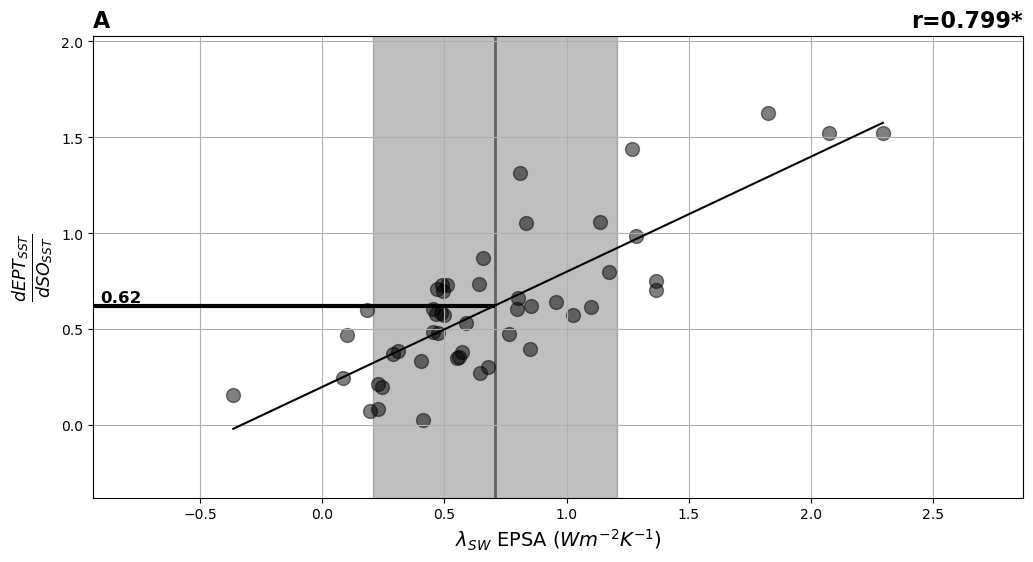

In [ ]:
title_fontsize = 16
fontsize=14
# Create figure and gridspec
fig = plt.figure(figsize=(12,6))
gs = fig.add_gridspec(1, 1, wspace=0.2, hspace=0.2)  # 2 rows, 2 columns

# Create scatter plots (top row)
ax1 = fig.add_subplot(gs[0, 0])

######## SWCF EPSA vs dEPT/dSO ############
y, x = get_shared_models(so_ept_pi["reg"].sel(years=12*5), so_ept_hi["reg"].sel(years=12*5))
create_panel_a(ax1, x.values, y.values, vline=[])
ax1.set_xlabel(r"$\lambda_{SW}$ EPSA ($Wm^{-2}K^{-1}$)", fontsize=fontsize)
ax1.set_ylabel(r"$\frac{d EPT_{SST}}{dSO_{SST}}$", fontsize=18)
ax1.set_title(r"A", loc="left", fontweight="bold", fontsize=title_fontsize)
ax1.grid()